In [ ]:
import xarray
import pandas as pd
import numpy as np

import datetime

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

import glob
from scipy.interpolate import RegularGridInterpolator

kk = 590
ee = 658

# Open HSRL file here.

In [ ]:
dat = '20191003'
base_date = pd.Timestamp('2019-10-03')
ds_nav = xarray.open_dataset(f'WWW-AIR_1726704979598/CAMP2EX-HSRL2_P3B_{dat}_R0.h5', engine='h5netcdf', 
                             phony_dims='access', group='Nav_Data')
base_jday = ds_nav['Jday'][:,0].values[0]
day_deltas = ds_nav['Jday'][:,0].values - base_jday
time_deltas = pd.to_timedelta(ds_nav['gps_time'][:,0].values, unit='h')
dates = base_date + pd.to_timedelta(day_deltas, unit='D')
date_times = dates + time_deltas
formatted_dates = date_times.strftime('%Y-%m-%d %H:%M:%S')

ds_nav['Date'] = xarray.DataArray(
    formatted_dates,
    dims=["time"]
)

df_nav = ds_nav['Date'].to_dataframe().reset_index()
df_nav['time'] = pd.to_datetime(df_nav['time'])

dat = '20191003'
dat1 = '2019-10-03-03600'
dat2 = '2019-10-04-03600'
workdir = 'WWW-AIR_1726704979598/'
p3file = f'CAMP2Ex-mrg01-P3B-NC_merge_{dat}_R3.nc'
p3data_ds = xarray.open_dataset(workdir+p3file)

variables = ['AOT532_hi', 'MLH']
selected_data = p3data_ds[variables]
p3data = selected_data.to_dataframe().reset_index()
p3data['time'] = pd.to_datetime(p3data['time'].dt.strftime("%Y-%m-%d %H:%M:%S"))

df_nav_ = pd.merge(df_nav, p3data, on='time', how='inner')

ds_one = xarray.open_dataset(f'WWW-AIR_1726704979598/CAMP2EX-HSRL2_P3B_{dat}_R0.h5', engine='h5netcdf', phony_dims='access', group='DataProducts')
variable_data = ds_one['532_ext']

# Open MUSICAv0 file here

In [10]:
def extract_level(df, lev):
    """
    Extract a single model level time series.
    lev: model level number (1–30)
    """
    return (
        df.loc[df['nl'] == (31 - lev), ['datetime', 'alt_mod']]
          .set_index('datetime')
          .to_xarray()
    )


In [ ]:
file_pattern = 'curtain_tracks/hsrl_20191003_curtain_CAMP2Ex.nc'
file_list = glob.glob(file_pattern)
# Open multiple NetCDF files and combine them into a single dataset
ds = xarray.open_mfdataset(file_list,combine='by_coords')
ds = ds.isel(Date=slice(kk, ee))
ds['Date'] = xarray.DataArray(
    pd.to_datetime(ds['Date'].values),
    dims='Date'
)
start = np.datetime64('2019-10-04 00:41:00')
end   = np.datetime64('2019-10-04 00:48:09')
ds = ds.sel(Date=slice(start, end))
average_per_altitude = ds.mean(dim='Date')
std_per_altitude = ds.std(dim='Date')

start = np.datetime64('2019-10-04 00:43:00')
end   = np.datetime64('2019-10-04 00:45:19')
ds_land = ds.sel(Date=slice(start, end))
average_per_altitude_land = ds_land.mean(dim='Date')
std_per_altitude_land = ds_land.std(dim='Date')

start = np.datetime64('2019-10-04 00:45:20')
end   = np.datetime64('2019-10-04T00:48:09')
ds_bay = ds.sel(Date=slice(start, end))
average_per_altitude_bay = ds_bay.mean(dim='Date')
std_per_altitude_bay = ds_bay.std(dim='Date')


In [27]:
average_per_altitude.to_dataframe().reset_index().to_csv('sample.csv')

In [ ]:
ds = xarray.open_mfdataset(file_list,combine='by_coords')
ds = ds.isel(Date=slice(kk, ee))

file_list = [
    "/home/svisaga/MUSICA_ANALYSES/curtain_tracks/p3_2019-10-03-03600_day1_curtain_MUSICAv0_7km_CAMP2Ex.nc",
    "/home/svisaga/MUSICA_ANALYSES/curtain_tracks/p3_2019-10-04-03600_day2_curtain_MUSICAv0_7km_CAMP2Ex.nc"
]
ds_mod = xarray.open_mfdataset(file_list,combine='by_coords')
df = ds_mod.to_dataframe().reset_index()

df['datetime'] = pd.to_datetime(df['datetime'])
startdate_ = '2019-10-04 00:41:00'
enddate_ = '2019-10-04 00:48:09'
df_mod = df[ (df['datetime']>=startdate_) &  (df['datetime']<=enddate_) ]
variables = ['datetime', 'alt_mod', 'EXTINCT_mod']
df_mod = df_mod[variables]


constant_altitudes = ds.Altitude.values

df_mod_interp = []

grouped = df_mod.groupby('datetime')

for name, group in grouped:
    
    group_sorted = group.sort_values('alt_mod')

    min_alt = group_sorted['alt_mod'].min()
    max_alt = group_sorted['alt_mod'].max()

    valid_altitudes = constant_altitudes[
        (constant_altitudes >= min_alt) & (constant_altitudes <= max_alt)
    ]

    interpolated = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['EXTINCT_mod'])

    interpolated_df = pd.DataFrame({
        'datetime': name,
        'altitude': valid_altitudes,
        'EXTINCT_mod': interpolated
    })

    df_mod_interp.append(interpolated_df)


df_mod_interp = pd.concat(df_mod_interp, ignore_index=True)

grouped_mean_ctrl = df_mod_interp.groupby('altitude').mean().reset_index()
grouped_std_ctrl = df_mod_interp.groupby('altitude').std().reset_index()

df_mod_interp_land = df_mod_interp[(df_mod_interp['datetime'] >= '2019-10-04 00:43:00')& (df_mod_interp['datetime'] <= '2019-10-04 00:45:19')]
grouped_mean_ctrl_land = df_mod_interp_land.groupby('altitude').mean().reset_index()
grouped_std_ctrl_land = df_mod_interp_land.groupby('altitude').std().reset_index()

df_mod_interp_bay = df_mod_interp[(df_mod_interp['datetime'] > '2019-10-04 00:45:19')]
grouped_mean_ctrl_bay = df_mod_interp_bay.groupby('altitude').mean().reset_index()
grouped_std_ctrl_bay = df_mod_interp_bay.groupby('altitude').std().reset_index()


/tmp/ipykernel_1677436/398119616.py:55: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_mean_ctrl = df_mod_interp.groupby('altitude').mean().reset_index()
/tmp/ipykernel_1677436/398119616.py:56: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_std_ctrl = df_mod_interp.groupby('altitude').std().reset_index()
/tmp/ipykernel_1677436/398119616.py:59: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_mean_ctr

In [ ]:
file_list = [
    "curtain_tracks_Exp01/p3_2019-10-03-03600_day1_curtain_MUSICAv0_7km_CAMP2Ex.nc",
    "curtain_tracks_Exp01/p3_2019-10-04-03600_day2_curtain_MUSICAv0_7km_CAMP2Ex.nc"
]

ds_mod = xarray.open_mfdataset(file_list,combine='by_coords')
df = ds_mod.to_dataframe().reset_index()

df['datetime'] = pd.to_datetime(df['datetime'])
startdate_ = '2019-10-04 00:41:00'
enddate_ = '2019-10-04 00:48:09'
df_mod = df[ (df['datetime']>=startdate_) &  (df['datetime']<=enddate_) ]
variables = ['datetime', 'alt_mod', 'EXTINCT_mod']
df_mod = df_mod[variables]


constant_altitudes = ds.Altitude.values

df_mod_interp = []

grouped = df_mod.groupby('datetime')

for name, group in grouped:
    group_sorted = group.sort_values('alt_mod')

    min_alt = group_sorted['alt_mod'].min()
    max_alt = group_sorted['alt_mod'].max()

    valid_altitudes = constant_altitudes[
        (constant_altitudes >= min_alt) & (constant_altitudes <= max_alt)
    ]

    interpolated = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['EXTINCT_mod'])

    interpolated_df = pd.DataFrame({
        'datetime': name,
        'altitude': valid_altitudes,
        'EXTINCT_mod': interpolated
    })

    df_mod_interp.append(interpolated_df)


df_mod_interp = pd.concat(df_mod_interp, ignore_index=True)

grouped_mean_exp01 = df_mod_interp.groupby('altitude').mean().reset_index()
grouped_std_exp01 = df_mod_interp.groupby('altitude').std().reset_index()

df_mod_interp_land = df_mod_interp[(df_mod_interp['datetime'] >= '2019-10-04 00:43:00')& (df_mod_interp['datetime'] <= '2019-10-04 00:45:19')]
grouped_mean_exp01_land = df_mod_interp_land.groupby('altitude').mean().reset_index()
grouped_std_exp01_land = df_mod_interp_land.groupby('altitude').std().reset_index()

df_mod_interp_bay = df_mod_interp[(df_mod_interp['datetime'] > '2019-10-04 00:45:19')]
grouped_mean_exp01_bay = df_mod_interp_bay.groupby('altitude').mean().reset_index()
grouped_std_exp01_bay = df_mod_interp_bay.groupby('altitude').std().reset_index()


/tmp/ipykernel_1677436/3397653878.py:53: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_mean_exp01 = df_mod_interp.groupby('altitude').mean().reset_index()
/tmp/ipykernel_1677436/3397653878.py:54: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_std_exp01 = df_mod_interp.groupby('altitude').std().reset_index()
/tmp/ipykernel_1677436/3397653878.py:57: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_mea

/home/svisaga/miniconda3/envs/cmp/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


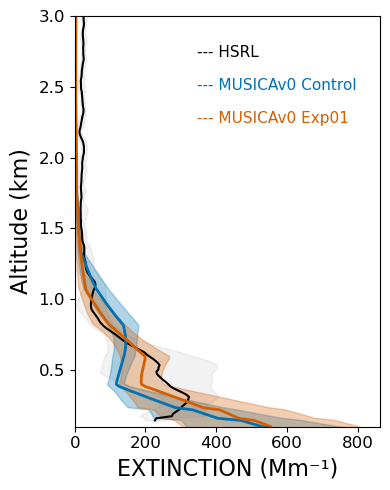

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

date_index = pd.DatetimeIndex(ds_nav['Date'][kk:ee].values)
lon_vals   = df_nav_['lon'].values[kk:ee]
mlh_vals   = df_nav_['MLH'].values[kk:ee]
time_vals  = df_nav_['time'].values[kk:ee]

tick_indices  = np.linspace(0, len(date_index) - 1, num=12, dtype=int)
tick_positions = date_index[tick_indices]
tick_labels    = [f"{lon_vals[i]:.2f}" for i in tick_indices]

fig, (ax0) = plt.subplots(
    1, 1, figsize=(4, 5)
)
fig.subplots_adjust(wspace=-0.3)


# =========================================================
# PANEL (a) — Column 1: Extinction Profiles
# =========================================================

# HSRL mean + std
ax0.plot(average_per_altitude['hsrl_532_ext']*1000,
         average_per_altitude['Altitude']/1000,
         color='k')

ax0.fill_betweenx(
    average_per_altitude['Altitude']/1000,
    1000*(average_per_altitude['hsrl_532_ext'] - std_per_altitude['hsrl_532_ext']),
    1000*(average_per_altitude['hsrl_532_ext'] + std_per_altitude['hsrl_532_ext']),
    color='gray', alpha=0.1
)

# MUSICAv0 Control
ax0.plot(grouped_mean_ctrl.EXTINCT_mod*1E6,
         grouped_mean_ctrl.altitude/1000,
         color='#0072B2', linewidth=2)

ax0.fill_betweenx(
    grouped_mean_ctrl.altitude/1000,
    1E6*(grouped_mean_ctrl.EXTINCT_mod - grouped_std_ctrl.EXTINCT_mod),
    1E6*(grouped_mean_ctrl.EXTINCT_mod + grouped_std_ctrl.EXTINCT_mod),
    color='#0072B2', alpha=0.3
)

# MUSICAv0 Exp01
ax0.plot(grouped_mean_exp01.EXTINCT_mod*1E6,
         grouped_mean_exp01.altitude/1000,
         color='#D55E00', linewidth=2)

ax0.fill_betweenx(
    grouped_mean_exp01.altitude/1000,
    1E6*(grouped_mean_exp01.EXTINCT_mod - grouped_std_exp01.EXTINCT_mod),
    1E6*(grouped_mean_exp01.EXTINCT_mod + grouped_std_exp01.EXTINCT_mod),
    color='#D55E00', alpha=0.3
)

# Text legend inside panel
ax0.text(0.4, 0.90, '--- HSRL', transform=ax0.transAxes, fontsize=11, color='k')
ax0.text(0.4, 0.82, '--- MUSICAv0 Control', transform=ax0.transAxes, fontsize=11, color='#0072B2')
ax0.text(0.4, 0.74, '--- MUSICAv0 Exp01', transform=ax0.transAxes, fontsize=11, color='#D55E00')


ax0.set_xlim(0, None)
ax0.set_ylim(0.1,3)
ax0.set_xlabel("EXTINCTION (Mm⁻¹)", fontsize=16)
ax0.set_ylabel("Altitude (km)", fontsize=16)
ax0.tick_params(labelsize=12)


plt.tight_layout()
plt.show()